# Getting started with iitx

`iitx` computes **integrated information** — the quantities of Integrated Information
Theory (IIT) — for any finite discrete dynamical system, in JAX. This notebook walks
through the core objects on the standard three-unit example, then shows the three
things that make `iitx` different from the reference implementation PyPhi: within-system
parallelism, batching across systems, and differentiation.

A system is just a **transition probability matrix** (TPM): `iitx` neither knows nor
cares whether it came from logic gates, a cellular automaton, a circuit, or a model of
a brain.

In [1]:
import jax

# IIT values are compared against reference values at up to 1e-13, so we compute in
# float64. (The library itself is dtype-polymorphic and never touches this flag.)
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from iitx.measures import iit3, iit4
from iitx.system import System

## A system and its state

The standard example of the IIT literature: three binary units, where unit 0 computes
OR of the others, unit 1 copies unit 2, and unit 2 computes XOR of units 0 and 1. We
give it in *state-by-node* form (each row: the probability of each unit turning ON,
given the previous joint state; rows are ordered little-endian — unit 0 varies
fastest), and analyze it in the state `(1, 0, 0)`.

In [2]:
tpm = jnp.asarray([
	[0.0, 0.0, 0.0],
	[0.0, 0.0, 1.0],
	[1.0, 0.0, 1.0],
	[1.0, 0.0, 0.0],
	[1.0, 1.0, 0.0],
	[1.0, 1.0, 1.0],
	[1.0, 1.0, 1.0],
	[1.0, 1.0, 0.0],
])
cm = jnp.asarray([[0, 0, 1], [1, 0, 1], [1, 1, 0]], dtype=bool)
system = System.from_state_by_node(tpm, cm=cm)
state = jnp.asarray([1, 0, 0])

system.shape, system.tpm.shape

((2, 2, 2), (8, 8))

## IIT 4.0: does the system exist as a whole, and as what?

**System integrated information** φ_s asks whether the system is irreducible: how much
intrinsic information about its own maximal cause-effect state is lost under the least
destructive partition. The **Φ-structure** unfolds *what* the system is: every
mechanism's causal distinction, the relations that bind them, and their total,
**big Φ**.

In [3]:
analysis = iit4.system_phi(system, state)
print(f"phi_s               = {analysis.phi:.6f}   (irreducible: the whole exists)")
print(f"cause state         = {analysis.cause_effect_state.cause_state}")
print(f"effect state        = {analysis.cause_effect_state.effect_state}")

structure = iit4.phi_structure(system, state)
exists = np.asarray(structure.distinctions.exists)
print(f"distinctions        = {int(exists.sum())}")
print(f"relations           = {int(structure.relations.count)}")
print(f"big Phi             = {structure.big_phi:.6f}")

phi_s               = 0.415037   (irreducible: the whole exists)
cause state         = [1 1 0]
effect state        = [0 0 1]


distinctions        = 2
relations           = 0
big Phi             = 1.000000


In [4]:
# The distinctions, mechanism by mechanism.
for k in np.flatnonzero(exists):
	mechanism = tuple(np.flatnonzero(np.asarray(structure.distinctions.mechanism)[k]))
	cause = tuple(np.flatnonzero(np.asarray(structure.distinctions.cause_purview)[k]))
	effect = tuple(np.flatnonzero(np.asarray(structure.distinctions.effect_purview)[k]))
	print(
		f"mechanism {mechanism}: phi_d = {float(structure.distinctions.phi[k]):.4f}"
		f"   cause purview {cause}, effect purview {effect}"
	)

mechanism (np.int64(1),): phi_d = 0.5000   cause purview (np.int64(2),), effect purview (np.int64(0),)
mechanism (np.int64(2),): phi_d = 0.5000   cause purview (np.int64(0), np.int64(1)), effect purview (np.int64(1),)


## IIT 3.0: concepts and big Φ

The 2014 formalism builds whole cause-effect *repertoires* per mechanism, measures
irreducibility by the earth mover's distance, and compares the whole constellation of
concepts against its minimal unidirectional cut. `iitx` reproduces PyPhi's numbers
(here, the famous Φ = 2.3125 with the cut (1,2) → (0,)) with exact — not approximate —
transport solves.

One honest caveat: those exact solves are host linear programs, so IIT 3.0 composes
with `jit` and `vmap` but deliberately refuses `grad`; IIT 4.0 is differentiable end
to end.

In [5]:
analysis3 = iit3.system_phi(system, state)
concepts = np.asarray(analysis3.ces.exists)
print(f"Phi (3.0)  = {analysis3.phi:.6f}")
print(f"concepts   = {int(concepts.sum())} with phi:",
      [round(float(x), 4) for x in np.asarray(analysis3.ces.phi)[concepts]])

Phi (3.0)  = 2.312499
concepts   = 4 with phi: [0.25, 0.5, 0.3333, 0.5]


## Batching: every state, every system, one call

Every analysis is a pure function of `(system, state)`, so `jax.vmap` batches it —
over states, over systems, or both. This is how you study the *landscape* of
integrated information rather than one point of it.

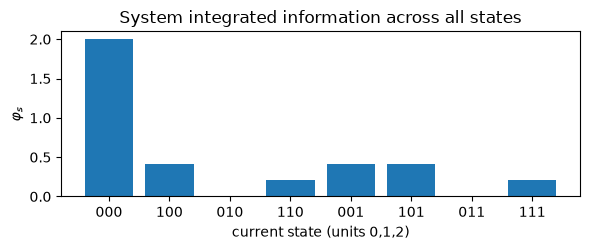

In [6]:
from iitx.states import all_states

states = jnp.asarray(all_states(system.shape))
batched = jax.jit(jax.vmap(iit4.system_phi, in_axes=(None, 0)))(system, states)

plt.figure(figsize=(6, 2.6))
plt.bar(range(8), np.asarray(batched.phi), color="tab:blue")
plt.xticks(range(8), ["".join(map(str, s)) for s in np.asarray(states)])
plt.xlabel("current state (units 0,1,2)")
plt.ylabel(r"$\varphi_s$")
plt.title("System integrated information across all states")
plt.tight_layout()

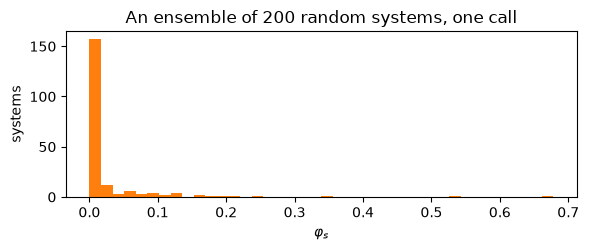

In [7]:
# An ensemble of 200 random stochastic systems, analyzed in one vmapped call.
rng = np.random.default_rng(0)
on = jnp.asarray(rng.random((200, 8, 3)))
ensemble = jax.vmap(System.from_state_by_node)(on)

phis = jax.jit(jax.vmap(iit4.system_phi, in_axes=(0, None)))(ensemble, state).phi
plt.figure(figsize=(6, 2.6))
plt.hist(np.asarray(phis), bins=40, color="tab:orange")
plt.xlabel(r"$\varphi_s$")
plt.ylabel("systems")
plt.title("An ensemble of 200 random systems, one call")
plt.tight_layout()

## Beyond binary: heterogeneous alphabets

Units can have any finite alphabet, and different units can have different alphabets —
which is exactly what coarse-graining produces. Here, a two-unit system where unit 0
has three states and unit 1 has two.

In [8]:
shape = (3, 2)
rng = np.random.default_rng(1)
factors = tuple(
	jnp.asarray(p / p.sum(axis=-1, keepdims=True))
	for p in (rng.random((*shape, q)) for q in shape)
)
nonbinary = System.from_node_tpms(factors)
print("phi_s of a (3, 2)-alphabet system:",
      float(iit4.system_phi(nonbinary, jnp.asarray([0, 0])).phi))

phi_s of a (3, 2)-alphabet system: 0.035078779780141685


## Macro levels: coarse-graining as a pure transform

A coarse-graining (unit partition + state grouping) maps a system to a *macro* system —
an ordinary `System` fed to the unchanged pipeline. PyPhi's classic example: four noisy
micro-units whose two-unit macro description is *more* integrated than the micro one.

In [9]:
from iitx.measures import iit3 as iit3_measure
from iitx.states import all_states as enumerate_states
from iitx.transforms import coarse_grain, coarse_grain_state

on = np.full((16, 4), 0.3)
for row, s in enumerate(enumerate_states((2, 2, 2, 2))):
	if s[0] and s[1]:
		on[row, 2:] = 1.0
	if s[2] and s[3]:
		on[row, :2] = 1.0
micro = System.from_state_by_node(jnp.asarray(on))
micro_state = jnp.asarray([0, 0, 0, 0])

grouping = (0, 0, 0, 1)  # a macro unit is ON when both its micro units are ON
macro = coarse_grain(micro, ((0, 1), (2, 3)), (grouping, grouping))
macro_state = coarse_grain_state(micro, ((0, 1), (2, 3)), (grouping, grouping), micro_state)

print(f"micro Phi (3.0) = {float(iit3_measure.system_phi(micro, micro_state).phi):.6f}")
print(f"macro Phi (3.0) = {float(iit3_measure.system_phi(macro, macro_state).phi):.6f}")

micro Phi (3.0) = 0.113889


macro Phi (3.0) = 0.869050


## Where next

- `01_ascending_phi.ipynb` — gradient ascent on integrated information itself, the
  library's flagship capability.
- `docs/design.md` — the core abstractions and why they look the way they do.
- `docs/notes/` — everything learned the hard way, including every documented
  divergence between the reference implementation and the papers.